# **Unknown Isolate — Species ID & AMR Profiling from Raw ONT Reads - Case analysis for Prof. Kılıç (Molecular Biology) — 15th Gen Internship Program**

### Candidate Name & email : Azra Tuncay - aazrtncy@gmail.com




In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

FASTQ = "/content/drive/MyDrive/unknown_isolate.fastq.gz"   # <-- edit if the find above showed a different path

assert os.path.exists(FASTQ), f"Not found at {FASTQ} — check the path against the 'find' output above"
size = os.path.getsize(FASTQ)
print("size (bytes):", size)
assert size > 400_000_000, "File looks truncated (expected ~459,915,593 bytes) — re-upload before continuing"

os.makedirs("/content/results", exist_ok=True)
os.makedirs("/content/dbs", exist_ok=True)

size (bytes): 459915593


In [3]:
%%bash
gzip -t /content/drive/MyDrive/unknown_isolate.fastq.gz && echo "gzip integrity: OK" || echo "gzip integrity: CORRUPT/TRUNCATED"
zcat /content/drive/MyDrive/unknown_isolate.fastq.gz 2>/dev/null | head -4

gzip integrity: OK
@read_000001
GATATGTGGCATGTCGCGGCTCACGATGGGCGCGCAAGAGATTTGTGGTTGAGTGGTCTGAAGGTTATTCCGCTCTATCGCCACGCGCAGCCAGTGTTGGTAATTCCTGACGAGATGACAGCAGAGCAGGCATATGAAATCAGATATTACTATGGAGACCCAGTCAACGTGTTGCCGCTGGGGCTAACA
+
%&(('&&'''&'''(--01188;=CCCEGJICC>><<<>BFEGD;BEEEFGMLI411)''&'',8:99:;;;<IIIHGEDDEBA?<9::;=;767778888566697779@BGJJJKJSIHEEGILK?===.--,,,---,-))))00,+,,,---BBBA@;74******0/.+*)%%%&&'2/6...,


In [4]:
%%bash
set -e
apt-get -qq update
# Colab runs Ubuntu 22.04 (jammy) — 'flye' isn't in apt until Ubuntu 24.04 (noble),
# so everything else installs via apt and Flye is built from source via pip below.
apt-get -qq install -y minimap2 samtools ncbi-blast+ mash bwa miniasm racon git build-essential zlib1g-dev > /dev/null

pip -q install biopython pandas matplotlib kleborate
# Flye: no PyPI wheel either, so install straight from the official GitHub source.
# Compiles a small amount of C++ under the hood (needs build-essential, installed above);
# takes a minute or two the first time.
pip -q install git+https://github.com/fenderglass/Flye.git

# seqkit isn't in apt; grab the official Go binary release instead of building from source
cd /tmp
curl -sL https://github.com/shenwei356/seqkit/releases/download/v2.8.2/seqkit_linux_amd64.tar.gz -o seqkit.tar.gz
tar xzf seqkit.tar.gz && chmod +x seqkit && mv seqkit /usr/local/bin/

# genus-agnostic MLST typer (Torsten Seemann) — ships its own pubMLST scheme cache, no separate DB download needed
git clone -q https://github.com/tseemann/mlst.git /opt/mlst
ln -sf /opt/mlst/bin/* /usr/local/bin/

echo "----- tool versions (copy these into findings.md) -----"
seqkit version
minimap2 --version
samtools --version | head -1
blastn -version | head -1
mash --version
flye --version
python3 -c "import kleborate; print('kleborate', kleborate.__version__)" 2>/dev/null || pip show kleborate | grep Version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 58.2 MB/s eta 0:00:00
----- tool versions (copy these into findings.md) -----
seqkit v2.8.2
2.24-r1122
samtools 1.13
blastn: 2.12.0+
2.3
2.9.6-b1802
Version: 3.2.4
                       Version 3, 29 June 2007
  5. Conveying Modified Source Versions.
  14. Revised Versions of this License.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [5]:
%%bash
seqkit stats -a /content/drive/MyDrive/unknown_isolate.fastq.gz | tee /content/results/seqkit_stats_raw.txt

file                                             format  type  num_seqs      sum_len  min_len  avg_len  max_len   Q1   Q2     Q3  sum_gap     N50  N50_num  Q20(%)  Q30(%)  AvgQual  GC(%)
/content/drive/MyDrive/unknown_isolate.fastq.gz  FASTQ   DNA    260,294  576,590,333        5  2,215.2  210,485  258  523  1,359        0  15,932    8,021   91.37   84.49    20.25  55.85


              length      mean_qual
count  260294.000000  260294.000000
mean     2215.150303      24.196756
std      6490.281484       6.734094
min         5.000000       5.510000
25%       258.000000      19.870000
50%       523.000000      23.680000
75%      1359.000000      27.540000
max    210485.000000      49.820000


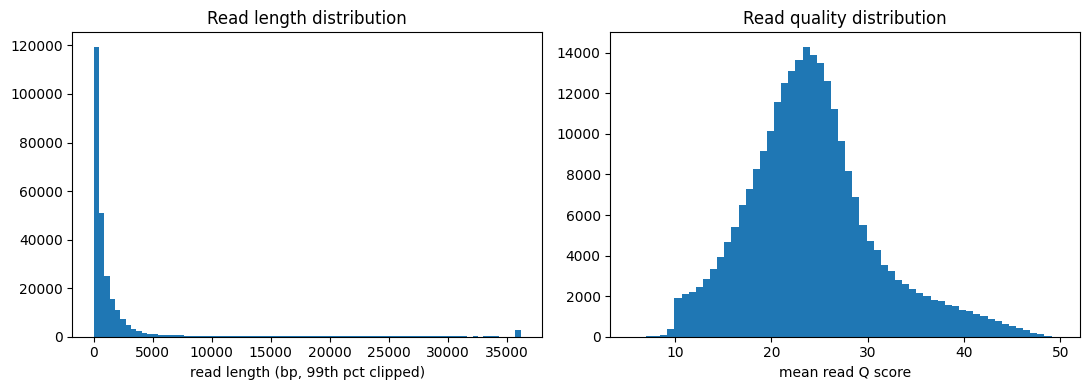

In [6]:
import pandas as pd, matplotlib.pyplot as plt, subprocess, io

result = subprocess.run(
    ["seqkit", "fx2tab", "-nlq", FASTQ],
    capture_output=True, text=True
)
if result.returncode != 0 or not result.stdout.strip():
    print("seqkit stderr:\n", result.stderr)
    raise RuntimeError("seqkit produced no output — the fastq is likely empty/unreadable. Stop and re-check Step 0.")

df = pd.read_csv(io.StringIO(result.stdout), sep="\t", header=None, names=["read_id", "length", "mean_qual"])
print(df[["length", "mean_qual"]].describe())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df["length"].clip(upper=df["length"].quantile(0.99)), bins=80)
ax[0].set_xlabel("read length (bp, 99th pct clipped)"); ax[0].set_title("Read length distribution")
ax[1].hist(df["mean_qual"], bins=60)
ax[1].set_xlabel("mean read Q score"); ax[1].set_title("Read quality distribution")
plt.tight_layout(); plt.savefig("/content/results/read_qc.png", dpi=140)
plt.show()

In [7]:
%%bash
# Drop very short reads — they add assembly-graph noise more than they add long-range information,
# and at 100x+ raw coverage I can afford to be selective.
seqkit seq -m 1000 /content/drive/MyDrive/unknown_isolate.fastq.gz -o /content/results/filtered_1kb.fastq.gz
seqkit stats -a /content/results/filtered_1kb.fastq.gz | tee /content/results/seqkit_stats_filtered.txt

file                                    format  type  num_seqs      sum_len  min_len  avg_len  max_len     Q1     Q2     Q3  sum_gap     N50  N50_num  Q20(%)  Q30(%)  AvgQual  GC(%)
/content/results/filtered_1kb.fastq.gz  FASTQ   DNA     83,661  506,811,866    1,000  6,057.9  210,485  1,416  2,120  4,238        0  20,154    6,472   91.49   84.74    20.28  56.07


[WARN] you may switch on flag -g/--remove-gaps to remove spaces


In [8]:
import subprocess
n_reads = int(subprocess.run(
    ["bash", "-c", "seqkit stats -T /content/results/filtered_1kb.fastq.gz | tail -1 | cut -f4"],
    capture_output=True, text=True
).stdout.strip())
print("filtered reads:", n_reads)
assert n_reads > 0, "Filtered fastq is empty — do NOT proceed to assembly, go back and check Step 0/1"

filtered reads: 83661


In [9]:
%%bash
curl -sL https://raw.githubusercontent.com/tseemann/abricate/master/db/card/sequences -o /content/dbs/card.fasta
minimap2 -x map-ont -t 2 --secondary=no -c /content/dbs/card.fasta /content/results/filtered_1kb.fastq.gz \
    > /content/results/reads_vs_card.paf 2> /content/results/reads_vs_card.log
echo "Distinct CARD reference genes with a read hit:"
awk '{print $6}' /content/results/reads_vs_card.paf | sort -u | wc -l
awk '{print $6}' /content/results/reads_vs_card.paf | sort | uniq -c | sort -rn | head -20

Distinct CARD reference genes with a read hit:
232
    326 card~~~Klebsiella_pneumoniae_OmpK37~~~AJ011502.1:300-1425~~~carbapenem;cephalosporin;monobactam;penicillin_beta-lactam
    223 card~~~AAC(6')-Ib7~~~KR091911.1:75350-74564~~~aminoglycoside
    190 card~~~aadA~~~AF550679.1:81768-80976~~~aminoglycoside
    159 card~~~aadA2~~~AF156486.1:5012-5792~~~aminoglycoside
    142 card~~~SHV-12~~~KF976405.1:7837-8698~~~cephalosporin;penicillin_beta-lactam
    134 card~~~acrD~~~AP009048.1:2586250-2589364~~~aminoglycoside
    121 card~~~catA1~~~V00622.1:243-903~~~phenicol
    118 card~~~APH(3')-Ia~~~BX664015.1:103833-103017~~~aminoglycoside
    115 card~~~OmpA~~~FO834906.1:2175099-2173974~~~peptide
    113 card~~~sul1~~~JF969163.1:1053-1893~~~sulfonamide
    113 card~~~Mrx~~~AY522923.1:8983-7744~~~macrolide
    112 card~~~mphA~~~D16251.1:2531-1625~~~macrolide
    107 card~~~oqxB~~~EU370913.1:47850-51003~~~diaminopyrimidine;fluoroquinolone;glycylcycline;nitrofuran;tetracycline
    107 card~~~df

In [10]:
!rm -rf /content/results/flye_asm

In [11]:
%%bash
flye \
  --nano-hq /content/results/filtered_1kb.fastq.gz \
  --out-dir /content/results/flye_asm \
  --threads 2 \
  2>&1 | tee /content/results/flye_run.log

[2026-07-28 23:07:42] INFO: Starting Flye 2.9.6-b1802
[2026-07-28 23:07:42] INFO: >>>STAGE: configure
[2026-07-28 23:07:42] INFO: Configuring run
[2026-07-28 23:07:53] INFO: Total read length: 506811866
[2026-07-28 23:07:53] INFO: Reads N50/N90: 20154 / 1903
[2026-07-28 23:07:53] INFO: Minimum overlap set to 2000
[2026-07-28 23:07:53] INFO: >>>STAGE: assembly
[2026-07-28 23:07:53] INFO: Assembling disjointigs
[2026-07-28 23:07:53] INFO: Reading sequences
[2026-07-28 23:08:02] INFO: Building minimizer index
[2026-07-28 23:08:02] INFO: Pre-calculating index storage
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
[2026-07-28 23:08:34] INFO: Filling index
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
[2026-07-28 23:11:02] INFO: Extending reads
[2026-07-28 23:13:07] INFO: Overlap-based coverage: 62
[2026-07-28 23:13:07] INFO: Median overlap divergence: 0.0111317
0% 10% 70% 80% 100% 
[2026-07-28 23:28:37] INFO: Assembled 7 disjointigs
[2026-07-28 23:28:37] INFO: Generating sequence
0% 10% 20% 30

In [12]:
import os, pandas as pd, subprocess

info_path = "/content/results/flye_asm/assembly_info.txt"
if not os.path.exists(info_path):
    log_path = "/content/results/flye_asm/flye.log"
    print("Flye did not produce an assembly.")
    if os.path.exists(log_path):
        print(subprocess.run(["tail", "-40", log_path], capture_output=True, text=True).stdout)
    else:
        print("No flye.log either — Flye likely crashed before starting. Check the flye_run.log output above.")
    raise RuntimeError("Assembly missing — see log tail above before continuing")

asm_info = pd.read_csv(info_path, sep="\t")
asm_info = asm_info.sort_values("length", ascending=False).reset_index(drop=True)
asm_info

,#seq_name,length,cov.,circ.,repeat,mult.,alt_group,graph_path
0,contig_3,5306069,75,Y,N,1,*,3
1,contig_8,214836,117,Y,N,1,*,8
2,contig_4,125021,188,Y,Y,2,*,4
3,contig_9,79498,122,Y,N,1,*,9
4,contig_7,41154,67,Y,N,1,*,7
5,contig_1,38533,824,N,Y,10,*,1
6,contig_6,35481,112,N,N,1,*,"*,6,*"
7,contig_2,3202,313,N,Y,4,*,2


In [13]:
%%bash
set -e
mkdir -p /content/dbs/16S_db
cd /content/dbs/16S_db
curl -sL https://ftp.ncbi.nlm.nih.gov/blast/db/16S_ribosomal_RNA.tar.gz -o 16S.tar.gz
tar xzf 16S.tar.gz
ls -la

blastn -query /content/results/flye_asm/assembly.fasta \
       -db /content/dbs/16S_db/16S_ribosomal_RNA \
       -out /content/results/16S_hits.tsv \
       -outfmt "6 qseqid sseqid pident length mismatch evalue bitscore stitle" \
       -max_target_seqs 5 -evalue 1e-50
sort -k1,1 -k7,7nr /content/results/16S_hits.tsv | sort -u -k1,1 --merge


total 370244
drwxr-xr-x 2 root root      4096 Jul 29 00:03 .
drwxr-xr-x 3 root root      4096 Jul 29 00:03 ..
-rw-rw-r-- 1 9011  990   1478656 Jul 23 09:36 16S_ribosomal_RNA.ndb
-rw-rw-r-- 1 9011  990   4372408 Jul 23 09:36 16S_ribosomal_RNA.nhr
-rw-rw-r-- 1 9011  990    331924 Jul 23 09:36 16S_ribosomal_RNA.nin
-rw-rw-r-- 1 9011  990    224072 Jul 23 09:36 16S_ribosomal_RNA.nnd
-rw-rw-r-- 1 9011  990       924 Jul 23 09:36 16S_ribosomal_RNA.nni
-rw-rw-r-- 1 9011  990    110624 Jul 23 09:36 16S_ribosomal_RNA.nog
-rw-rw-r-- 1 9011  990    557300 Jul 23 09:36 16S_ribosomal_RNA.nos
-rw-rw-r-- 1 9011  990    332196 Jul 23 09:36 16S_ribosomal_RNA.not
-rw-rw-r-- 1 9011  990  10141831 Jul 23 09:36 16S_ribosomal_RNA.nsq
-rw-rw-r-- 1 9011  990    679936 Jul 23 09:36 16S_ribosomal_RNA.ntf
-rw-rw-r-- 1 9011  990    198016 Jul 23 09:36 16S_ribosomal_RNA.nto
-rw-r--r-- 1 root root  71515292 Jul 29 00:03 16S.tar.gz
-rw-rw-r-- 1 9011  990 176426787 Jul 23 09:36 taxdb.btd
-rw-rw-r-- 1 9011  990  18429

In [14]:
import pandas as pd
cols = ["query_contig","subject_acc","pct_id","aln_len","mismatches","evalue","bitscore","subject_title"]
hits16s = pd.read_csv("/content/results/16S_hits.tsv", sep="\t", header=None, names=cols)
best_per_contig = hits16s.sort_values("bitscore", ascending=False).drop_duplicates("query_contig")
best_per_contig

,query_contig,subject_acc,pct_id,aln_len,mismatches,evalue,bitscore,subject_title
0,contig_3,gi|645320489|ref|NR_117683.1|,99.738,1529,4,0.0,2802,Klebsiella pneumoniae strain DSM 30104 16S rib...


In [20]:
%%bash
apt-get -qq install -y libjson-perl liblist-moreutils-perl
echo "--- apt exit code: $? ---"
perl -MJSON -e 'print "JSON module: OK\n"' 2>&1
perl -MList::MoreUtils -e 'print "List::MoreUtils: OK\n"' 2>&1

Selecting previously unselected package libcommon-sense-perl:amd64.
(Reading database ... 118750 files and directories currently installed.)
Preparing to unpack .../libcommon-sense-perl_3.75-2build1_amd64.deb ...
Unpacking libcommon-sense-perl:amd64 (3.75-2build1) ...
Selecting previously unselected package libjson-perl.
Preparing to unpack .../libjson-perl_4.04000-1_all.deb ...
Unpacking libjson-perl (4.04000-1) ...
Selecting previously unselected package libtypes-serialiser-perl.
Preparing to unpack .../libtypes-serialiser-perl_1.01-1_all.deb ...
Unpacking libtypes-serialiser-perl (1.01-1) ...
Selecting previously unselected package libjson-xs-perl.
Preparing to unpack .../libjson-xs-perl_4.040-0ubuntu0.22.04.1_amd64.deb ...
Unpacking libjson-xs-perl (4.040-0ubuntu0.22.04.1) ...
Setting up libcommon-sense-perl:amd64 (3.75-2build1) ...
Setting up libtypes-serialiser-perl (1.01-1) ...
Setting up libjson-perl (4.04000-1) ...
Setting up libjson-xs-perl (4.040-0ubuntu0.22.04.1) ...
Proces

In [22]:
%%bash
apt-get -qq install -y libmoo-perl libtype-tiny-perl libfile-slurp-perl libpath-tiny-perl liblwp-simple-perl libwww-perl libjson-perl liblist-moreutils-perl libdata-dumper-simple-perl
echo "--- apt exit code: $? ---"

--- apt exit code: 100 ---


E: Unable to locate package liblwp-simple-perl


In [24]:
%%bash
cpanm --notest Moo Type::Tiny 2>&1 | tail -30

bash: line 1: cpanm: command not found


In [25]:
%%bash
apt-get -qq install -y cpanminus
echo "--- apt exit: $? ---"
which cpanm
cpanm --notest Moo Type::Tiny 2>&1 | tail -40

Selecting previously unselected package libcpan-distnameinfo-perl.
(Reading database ... 118803 files and directories currently installed.)
Preparing to unpack .../00-libcpan-distnameinfo-perl_0.12-2.1_all.deb ...
Unpacking libcpan-distnameinfo-perl (0.12-2.1) ...
Selecting previously unselected package libcpan-meta-check-perl.
Preparing to unpack .../01-libcpan-meta-check-perl_0.014-1_all.deb ...
Unpacking libcpan-meta-check-perl (0.014-1) ...
Selecting previously unselected package libfile-pushd-perl.
Preparing to unpack .../02-libfile-pushd-perl_1.016-1_all.deb ...
Unpacking libfile-pushd-perl (1.016-1) ...
Selecting previously unselected package libmodule-build-perl.
Preparing to unpack .../03-libmodule-build-perl_0.423100-1_all.deb ...
Adding 'diversion of /usr/bin/config_data to /usr/bin/config_data.diverted by libmodule-build-perl'
Adding 'diversion of /usr/share/man/man1/config_data.1.gz to /usr/share/man/man1/config_data.diverted.1.gz by libmodule-build-perl'
Unpacking libmodu

In [27]:
%%bash
perl -c /usr/local/bin/mlst 2>&1

/usr/local/bin/mlst syntax OK


In [29]:
%%bash
curl -sL https://raw.githubusercontent.com/tseemann/any2fasta/master/any2fasta -o /usr/local/bin/any2fasta
chmod +x /usr/local/bin/any2fasta
any2fasta -h 2>&1 | head -5

NAME
  any2fasta 0.9.0
SYNOPSIS
  Convert various sequence formats into FASTA
USAGE


In [31]:
%%bash
mlst --list | grep -i kleb

aactinomycetemcomitans abaumannii abaumannii_2 achromobacter aeromonas aparagallinarum aphagocytophilum arcobacter bbacilliformis bcc bcereus bfragilis bhenselae blicheniformis_14 bordetella_3 borrelia bpseudomallei brachyspira brachyspira_2 brachyspira_3 brachyspira_4 brachyspira_5 brucella bsubtilis bwashoensis campylobacter campylobacter_nonjejuni campylobacter_nonjejuni_2 campylobacter_nonjejuni_3 campylobacter_nonjejuni_4 campylobacter_nonjejuni_5 campylobacter_nonjejuni_6 campylobacter_nonjejuni_7 campylobacter_nonjejuni_8 campylobacter_nonjejuni_9 cbotulinum cdifficile cdiphtheriae cfreundii chlamydiales cmaltaromaticum cperfringens cronobacter csepticum diphtheria_3 dnodosus ecloacae ecoli ecoli_achtman_4 edwardsiella efaecalis efaecium fpsychrophilum gallibacterium geotrichum halobacteria hcinaedi helicobacter hinfluenzae hparasuis hsuis kaerogenes kingella klebsiella koxytoca leptospira leptospira_2 leptospira_3 lgarvieae liberibacter listeria_2 llactis_phage lsalivarius mabs

This is mlst 2.35.0 running on linux with Perl 5.034000
Checking mlst dependencies:
Found 'blastn' => /usr/bin/blastn
Found 'any2fasta' => /usr/local/bin/any2fasta


In [33]:
%%bash
set -e
mlst /content/results/flye_asm/assembly.fasta | tee /content/results/mlst_result.tsv
test -s /content/results/mlst_result.tsv || { echo "mlst produced no output — check PATH/install"; exit 1; }

/content/results/flye_asm/assembly.fasta	klebsiella	258	gapA(3)	infB(3)	mdh(1)	pgi(1)	phoE(1)	rpoB(1)	tonB(79)


This is mlst 2.35.0 running on linux with Perl 5.034000
Checking mlst dependencies:
Found 'blastn' => /usr/bin/blastn
Found 'any2fasta' => /usr/local/bin/any2fasta
Excluding 4 schemes: vcholerae_2 ecoli senterica_achtman_2 abaumannii
Running: any2fasta -q \/content\/results\/flye_asm\/assembly\.fasta > /tmp/fyVUQUro41/mlst.fna
Running:  blastn -query /tmp/fyVUQUro41/mlst.fna -out /tmp/fyVUQUro41/mlst.bls -db \/opt\/mlst\/db\/blast\/mlst\.fa -num_threads 1 -ungapped -dust no -word_size 32 -max_target_seqs 100000 -perc_identity 95 -evalue 1E-20 -outfmt '6 sseqid slen length nident qseqid qstart qend qseq sstrand'
Found exact allele match kaerogenes.fusA-38
Found exact allele match kaerogenes.rplB-27
Found exact allele match ecloacae.rplB-311
Found exact allele match ecoli_achtman_4.adk-1769
Found exact allele match ecoli_achtman_4.icd-1804
Found exact allele match ecoli_achtman_4.recA-866
Found exact allele match klebsiella.rpoB-1
Found exact allele match ecoli_achtman_4.purA-745
Found e

In [34]:
# Klebsiella-specific typing — ONLY meaningful if the 16S call above says Klebsiella / KpSC.
# Edit the guard below once you've looked at best_per_contig from the previous cell.
IS_KLEBSIELLA = True   # confirmed: chromosomal SHV/LEN/oqxAB signature + VFDB hits tagged [Klebsiella pneumoniae subsp. pneumoniae NTUH-K2044]

if IS_KLEBSIELLA:
    import subprocess
    subprocess.run([
        "kleborate", "-a", "/content/results/flye_asm/assembly.fasta",
        "-o", "/content/results/kleborate_out", "-p", "kpsc"
    ], check=True)
    import pandas as pd
    display(pd.read_csv("/content/results/kleborate_out/klebsiella_pneumo_complex_output.txt", sep="\t"))
else:
    print("Skipping Kleborate — 16S call was not Klebsiella. Relying on generic MLST above.")

,strain,enterobacterales__species__species,enterobacterales__species__species_match,general__contig_stats__contig_count,general__contig_stats__N50,general__contig_stats__largest_contig,general__contig_stats__total_size,general__contig_stats__ambiguous_bases,general__contig_stats__QC_warnings,klebsiella_pneumo_complex__mlst__ST,...,klebsiella_pneumo_complex__kaptive__K_locus_confidence,klebsiella_pneumo_complex__kaptive__K_locus_problems,klebsiella_pneumo_complex__kaptive__K_locus_identity,klebsiella_pneumo_complex__kaptive__K_Missing_expected_genes,klebsiella_pneumo_complex__kaptive__O_locus,klebsiella_pneumo_complex__kaptive__O_type,klebsiella_pneumo_complex__kaptive__O_locus_confidence,klebsiella_pneumo_complex__kaptive__O_locus_problems,klebsiella_pneumo_complex__kaptive__O_locus_identity,klebsiella_pneumo_complex__kaptive__O_Missing_expected_genes
0,assembly,Klebsiella pneumoniae,strong,8,5306069,5306069,5843794,no,-,ST258,...,Typeable,-,99.97%,-,OL13,O13,Untypeable,-,98.26%,OL13_07_wzt;OL13_09_glycosylhydrolase;OL13_08_...


In [35]:
%%bash
set -e
cd /content/dbs
for db in card resfinder plasmidfinder vfdb argannot; do
  curl -sL "https://raw.githubusercontent.com/tseemann/abricate/master/db/${db}/sequences" -o "${db}.fasta"
  echo "$db: $(grep -c '^>' ${db}.fasta) sequences"
done
echo "Databases fetched: $(date -u '+%Y-%m-%d %H:%M UTC')"   # <-- copy this timestamp into findings.md
curl -s "https://api.github.com/repos/tseemann/abricate/commits?path=db&per_page=1" | \
  python3 -c "import sys,json; d=json.load(sys.stdin); print('abricate db/ last commit:', d[0]['sha'][:10], d[0]['commit']['committer']['date'])"

card: 6052 sequences
resfinder: 3206 sequences
plasmidfinder: 488 sequences
vfdb: 4592 sequences
argannot: 2224 sequences
Databases fetched: 2026-07-29 00:14 UTC
abricate db/ last commit: f56f5cee6b 2026-04-03T02:01:42Z


In [36]:
%%bash
cd /content/dbs
for db in card resfinder plasmidfinder vfdb argannot; do
  makeblastdb -in ${db}.fasta -dbtype nucl -out ${db}_db > /dev/null
done

ASM=/content/results/flye_asm/assembly.fasta
mkdir -p /content/results/blast
for db in card resfinder plasmidfinder vfdb argannot; do
  blastn -query $ASM -db /content/dbs/${db}_db \
    -outfmt "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore qlen slen stitle" \
    -evalue 1e-20 -out /content/results/blast/${db}_hits.tsv
done
wc -l /content/results/blast/*_hits.tsv

   873 /content/results/blast/argannot_hits.tsv
  1452 /content/results/blast/card_hits.tsv
    32 /content/results/blast/plasmidfinder_hits.tsv
  1061 /content/results/blast/resfinder_hits.tsv
    82 /content/results/blast/vfdb_hits.tsv
  3500 total


In [37]:
import pandas as pd

cols = ["contig","subject","pct_id","aln_len","mismatches","gapopen","qstart","qend",
        "sstart","send","evalue","bitscore","qlen","slen","subject_title"]

def load_hits(db, min_id=90, min_cov=80):
    df = pd.read_csv(f"/content/results/blast/{db}_hits.tsv", sep="\t", header=None, names=cols)
    df["pct_cov_of_ref"] = 100 * df["aln_len"] / df["slen"]
    # Keep only hits that look like the real gene, not a fragment or distant homolog:
    # identity threshold distinguishes "this gene" from "a relative of this gene";
    # coverage threshold distinguishes "the whole gene" from "a chunk of it".
    filt = df[(df["pct_id"] >= min_id) & (df["pct_cov_of_ref"] >= min_cov)].copy()
    filt["db"] = db
    return filt.sort_values(["contig","bitscore"], ascending=[True, False])

amr = pd.concat([load_hits(d) for d in ["card","resfinder","argannot"]], ignore_index=True)
plasmid_replicons = load_hits("plasmidfinder", min_id=90, min_cov=60)
virulence = load_hits("vfdb", min_id=90, min_cov=80)

amr.to_csv("/content/results/resistance_summary.tsv", sep="\t", index=False)
plasmid_replicons.to_csv("/content/results/plasmid_replicons.tsv", sep="\t", index=False)
virulence.to_csv("/content/results/virulence_summary.tsv", sep="\t", index=False)

print("=== Candidate resistance genes (CARD + ResFinder + ARG-ANNOT, >=90% id, >=80% coverage) ===")
display(amr[["contig","subject_title","pct_id","pct_cov_of_ref","db"]])

=== Candidate resistance genes (CARD + ResFinder + ARG-ANNOT, >=90% id, >=80% coverage) ===


,contig,subject_title,pct_id,pct_cov_of_ref,db
0,contig_3,card~~~oqxB~~~EU370913.1:47850-51003~~~diamino...,100.000,100.000000,card
1,contig_3,card~~~LptD~~~CP007727.1:809555-807206~~~amino...,100.000,100.000000,card
2,contig_3,card~~~eptB~~~FO203501.1:5123640-5125365~~~pep...,99.652,100.000000,card
3,contig_3,card~~~ArnT~~~FO834906.1:304977-306633~~~pepti...,99.819,100.000000,card
4,contig_3,card~~~MdtQ~~~CP133868.1:5053037-5051597~~~car...,99.375,100.000000,card
...,...,...,...,...,...
2390,contig_9,argannot~~~(AGly)aadA8b~~~AM040708:1174-1965~~...,91.919,100.000000,argannot
2391,contig_9,argannot~~~(AGly)aadA8~~~AF326210:1-792~~~ (AG...,91.667,100.000000,argannot
2392,contig_9,argannot~~~(AGly)aadA3~~~AF047479:1296-2087~~~...,90.530,100.000000,argannot
2393,contig_9,argannot~~~(AGly)aacA4~~~AF416297:2738-3304~~~...,99.469,99.647266,argannot


In [38]:
import pandas as pd

asm_info2 = pd.read_csv("/content/results/flye_asm/assembly_info.txt", sep="\t")
asm_info2 = asm_info2.rename(columns={"#seq_name": "contig"})

def genes_per_contig(df):
    return df.groupby("contig")["subject_title"].apply(lambda s: "; ".join(sorted(set(s)))).to_dict()

amr_by_contig = genes_per_contig(amr)
vf_by_contig = genes_per_contig(virulence)
rep_by_contig = genes_per_contig(plasmid_replicons)

asm_info2["AMR_genes"] = asm_info2["contig"].map(amr_by_contig).fillna("-")
asm_info2["virulence_genes"] = asm_info2["contig"].map(vf_by_contig).fillna("-")
asm_info2["plasmid_replicon"] = asm_info2["contig"].map(rep_by_contig).fillna("-")

# Simple, transparent heuristic for the chromosome/plasmid call — not a black box:
#   - the largest contig, roughly single-copy coverage -> chromosome
#   - smaller + circular + has a PlasmidFinder replicon hit -> plasmid, high confidence
#   - smaller + circular but NO replicon hit -> plasmid, lower confidence (note this in the report)
def call_type(row):
    if row["length"] == asm_info2["length"].max() and row["length"] > 2_000_000:
        return "chromosome (largest contig)"
    if row["circ."] == "Y" and row["plasmid_replicon"] != "-":
        return "plasmid (circular + replicon match)"
    if row["circ."] == "Y":
        return "plasmid? (circular, no replicon hit — lower confidence)"
    return "unresolved fragment"

asm_info2["call"] = asm_info2.apply(call_type, axis=1)
asm_info2.to_csv("/content/results/contig_summary.tsv", sep="\t", index=False)
asm_info2

,contig,length,cov.,circ.,repeat,mult.,alt_group,graph_path,AMR_genes,virulence_genes,plasmid_replicon,call
0,contig_3,5306069,75,Y,N,1,*,3,argannot~~~(Bla)ampH~~~CP003785:4208384-420954...,vfdb~~~KP1_RS17355~~~WP_014907219~~~ (KP1_RS17...,-,chromosome (largest contig)
1,contig_8,214836,117,Y,N,1,*,8,argannot~~~(AGly)aadA11~~~AJ567827:1-792~~~ (A...,-,plasmidfinder~~~IncFIB(K)(pCAV1099-114)_1~~~CP...,plasmid (circular + replicon match)
2,contig_4,125021,188,Y,Y,2,*,4,argannot~~~(Bla)blaLEN-10~~~AJ635419:1-789~~~ ...,-,plasmidfinder~~~IncFII(Yp)_1_Yersenia~~~CP0006...,plasmid (circular + replicon match)
3,contig_9,79498,122,Y,N,1,*,9,argannot~~~(AGly)aac6-Ib~~~M21682:380-985~~~ (...,-,plasmidfinder~~~IncI2_1_Delta~~~AP002527~~~ In...,plasmid (circular + replicon match)
4,contig_7,41154,67,Y,N,1,*,7,argannot~~~(AGly)aac-IVa~~~X01385:244-1029~~~ ...,-,plasmidfinder~~~IncR_1~~~DQ449578~~~ IncR_1__D...,plasmid (circular + replicon match)
5,contig_1,38533,824,N,Y,10,*,1,-,-,-,unresolved fragment
6,contig_6,35481,112,N,N,1,*,"*,6,*",-,-,-,unresolved fragment
7,contig_2,3202,313,N,Y,4,*,2,-,-,-,unresolved fragment


In [39]:
%%bash
cd /content/results && zip -qr /content/results_bundle.zip . && ls -la /content/results_bundle.zip
echo "Now download /content/results_bundle.zip from the Colab Files sidebar (or copy it to Drive)."

-rw-r--r-- 1 root root 435606089 Jul 29 00:15 /content/results_bundle.zip
Now download /content/results_bundle.zip from the Colab Files sidebar (or copy it to Drive).


In [40]:
# Optional: save the results bundle straight to Drive instead of downloading it manually
import shutil
shutil.copy("/content/results_bundle.zip", "/content/drive/MyDrive/results_bundle.zip")
print("Copied to /content/drive/MyDrive/results_bundle.zip")

Copied to /content/drive/MyDrive/results_bundle.zip
